# VAE Evaluation — Phase 3E  *(v2)*

**Prerequisite**: `dvc repro train_vae` must have completed before running this notebook.

---

## What is the VAE doing in this pipeline?

The VAE is **not** used as a generative model here. Its sole job is to act as a learned encoder:

```
X (26 raw features)  →  Encoder  →  Z (32-dim latent space)  →  ML / DL classifier
```

The decoder only appears in **this notebook** as a diagnostic tool — it is never called during training or inference.  
The latent space `Z` is also where **LSA augmentation** (Latent Space Augmentation) operates: synthetic fatal-class
samples are sampled as Gaussian noise around the fatal centroid in `Z`, then fed directly to the classifier.

Because of this, the questions that matter are:

| Priority | Question | Section |
|---|---|---|
| 1 | Does `Z` separate severity classes? | §1 |
| 2 | Which latent dimensions carry real structure (vs collapsed to noise)? | §2 |
| 3 | Is the fatal-class cluster in `Z` tight enough for LSA to produce useful synthetics? | §3 |
| 4 | Is the encoder learning a reasonable representation? *(sanity check only)* | §4 |

In [5]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import yaml
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from src.train_vae.vae_trainer import Encoder, Decoder

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

CLASS_NAMES  = ['PDO', 'Injury', 'Fatal']
CLASS_COLORS = ['#4e79a7', '#f28e2b', '#e15759']
PROCESSED    = ROOT / 'data' / 'processed'
MODELS       = ROOT / 'models'

In [6]:
# ── data ──────────────────────────────────────────────────────────────────────
X_train = np.load(PROCESSED / 'X_train.npy')
X_val   = np.load(PROCESSED / 'X_val.npy')
X_test  = np.load(PROCESSED / 'X_test.npy')
y_train = np.load(PROCESSED / 'y_train.npy')
y_val   = np.load(PROCESSED / 'y_val.npy')
y_test  = np.load(PROCESSED / 'y_test.npy')

X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

counts = dict(zip(*np.unique(y_all, return_counts=True)))
print(f'Dataset: {len(X_all):,} samples × {X_all.shape[1]} features')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<8}: {counts[i]:>6,}  ({counts[i]/len(y_all):.1%})')

# ── feature names (ColumnTransformer order: num → cat → cyc → ord) ───────────
with open(ROOT / 'params.yaml') as f:
    params = yaml.safe_load(f)

fc           = params['features']
numeric_cols = fc['numeric_columns']
ordinal_cols = list(fc['ordinal_columns'].keys())
cyclical_cols = fc.get('cyclical_columns', {})

# Remove cyclical columns from their original groups (HOUR was numeric, MONTH was ordinal)
# They are now replaced by sin/cos pairs in the 'cyc' transformer group
numeric_cols = [c for c in numeric_cols if c not in cyclical_cols]
ordinal_cols = [c for c in ordinal_cols if c not in cyclical_cols]

# Build cyclical column names (sin/cos pairs)
cyc_cols = []
for col in sorted(cyclical_cols.keys()):  # sorted for consistent order
    cyc_cols.extend([f'{col}_sin', f'{col}_cos'])

cat_cols = [c for c in fc['columns'] 
            if c not in fc['numeric_columns'] 
            and c not in fc['ordinal_columns'] 
            and c not in cyclical_cols]

# ColumnTransformer output order: num → cat → cyc → ord
feature_names = numeric_cols + cat_cols + cyc_cols + ordinal_cols
feature_type  = (
    ['numeric']     * len(numeric_cols)
    + ['categorical'] * len(cat_cols)
    + ['cyclical']    * len(cyc_cols)
    + ['ordinal']     * len(ordinal_cols)
)

assert len(feature_names) == X_all.shape[1], (
    f'Feature count mismatch: params has {len(feature_names)}, X_all has {X_all.shape[1]} cols'
)

# ── model ─────────────────────────────────────────────────────────────────────
enc_ckpt = torch.load(MODELS / 'vae_encoder.pth', weights_only=True)
dec_ckpt = torch.load(MODELS / 'vae_decoder.pth', weights_only=True)

if enc_ckpt['input_dim'] != X_all.shape[1]:
    raise RuntimeError(
        f"Stale checkpoint: input_dim={enc_ckpt['input_dim']} "
        f"but X_all has {X_all.shape[1]} columns. Run `dvc repro train_vae`."
    )

encoder = Encoder(enc_ckpt['input_dim'], enc_ckpt['encoder_dims'], enc_ckpt['latent_dim'])
encoder.load_state_dict(enc_ckpt['state_dict']); encoder.eval()
decoder = Decoder(dec_ckpt['latent_dim'], dec_ckpt['decoder_dims'], dec_ckpt['output_dim'])
decoder.load_state_dict(dec_ckpt['state_dict']); decoder.eval()

print(f'\nEncoder: {enc_ckpt["input_dim"]}d → {enc_ckpt["encoder_dims"]} → latent {enc_ckpt["latent_dim"]}d')

# ── forward pass (mean path — deterministic) ──────────────────────────────────
with torch.no_grad():
    mu, log_var = encoder(torch.tensor(X_all, dtype=torch.float32))
    X_hat       = decoder(mu)

Z   = mu.numpy()        # (N, 32)  — latent means used by downstream classifier
lv  = log_var.numpy()   # (N, 32)  — log-variance of posterior
X_r = X_hat.numpy()     # (N, 26)  — decoder reconstruction (diagnostic only)

print(f'Latent space Z: {Z.shape}')

Dataset: 74,309 samples × 28 features
  PDO     : 60,761  (81.8%)
  Injury  : 13,443  (18.1%)
  Fatal   :    105  (0.1%)

Encoder: 28d → [256, 128, 64] → latent 32d
Latent space Z: (74309, 32)


---
## §1 — Does Z separate severity classes?

**Why this matters**: the downstream classifier trains entirely on `Z`. If the three classes
overlap completely in latent space the classifier has nothing to learn from.

**How to read the plots**:
- Perfect separation is not expected — the VAE was trained **unsupervised** (no labels).
  Any class structure that emerges means the encoder found a feature configuration that
  correlates with severity without being told to.
- Look for **partial separation** of the Fatal cluster (red). Even a loose cluster means
  LSA augmentation will produce synthetic samples that resemble real fatals.
- PCA is linear and fast (uses full 74 k points). t-SNE is non-linear and slower
  (8 k subsample) but reveals local neighbourhood structure that PCA misses.

Running t-SNE …
Done.


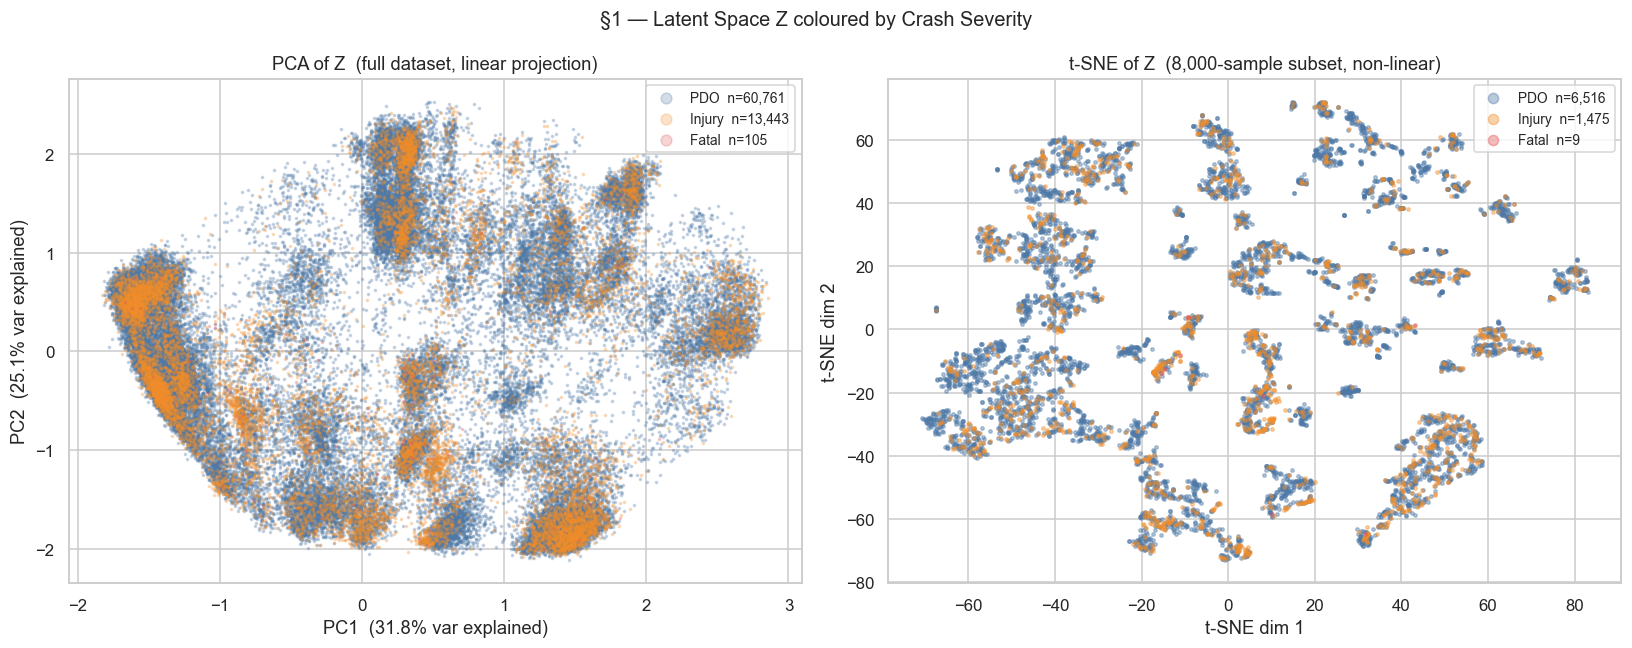

In [7]:
pca     = PCA(n_components=2, random_state=42)
Z_pca   = pca.fit_transform(Z)
var_exp = pca.explained_variance_ratio_ * 100

# t-SNE on stratified subsample
N_TSNE  = 8000
rng     = np.random.default_rng(42)
idx     = rng.choice(len(Z), size=N_TSNE, replace=False)
print('Running t-SNE …')
Z_tsne  = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(Z[idx])
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for cls_id, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = y_all == cls_id
    axes[0].scatter(Z_pca[mask, 0], Z_pca[mask, 1],
                    s=2, alpha=0.25, color=color, label=f'{name}  n={mask.sum():,}')
axes[0].set_title('PCA of Z  (full dataset, linear projection)')
axes[0].set_xlabel(f'PC1  ({var_exp[0]:.1f}% var explained)')
axes[0].set_ylabel(f'PC2  ({var_exp[1]:.1f}% var explained)')
axes[0].legend(markerscale=5, fontsize=9)

for cls_id, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = y_all[idx] == cls_id
    axes[1].scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                    s=5, alpha=0.4, color=color, label=f'{name}  n={mask.sum():,}')
axes[1].set_title(f't-SNE of Z  ({N_TSNE:,}-sample subset, non-linear)')
axes[1].set_xlabel('t-SNE dim 1')
axes[1].set_ylabel('t-SNE dim 2')
axes[1].legend(markerscale=3, fontsize=9)

fig.suptitle('§1 — Latent Space Z coloured by Crash Severity', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Interactive 3D PCA with Plotly (can rotate, zoom, pan)
import plotly.graph_objects as go

pca_3d_plotly = PCA(n_components=3, random_state=42)
Z_pca_3d_plotly = pca_3d_plotly.fit_transform(Z)
var_exp_3d_plotly = pca_3d_plotly.explained_variance_ratio_ * 100

fig = go.Figure()

for cls_id, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = y_all == cls_id
    fig.add_trace(go.Scatter3d(
        x=Z_pca_3d_plotly[mask, 0],
        y=Z_pca_3d_plotly[mask, 1],
        z=Z_pca_3d_plotly[mask, 2],
        mode='markers',
        name=f'{name} (n={mask.sum():,})',
        marker=dict(
            size=2,
            color=color,
            opacity=0.4
        )
    ))

fig.update_layout(
    title='Interactive 3D PCA of Latent Space Z (full dataset)',
    scene=dict(
        xaxis_title=f'PC1 ({var_exp_3d_plotly[0]:.1f}%)',
        yaxis_title=f'PC2 ({var_exp_3d_plotly[1]:.1f}%)',
        zaxis_title=f'PC3 ({var_exp_3d_plotly[2]:.1f}%)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2)
        )
    ),
    width=900,
    height=700,
    showlegend=True
)

fig.show()

print(f'Cumulative variance (PC1+PC2+PC3): {var_exp_3d_plotly.sum():.1f}%')
print('💡 Click and drag to rotate, scroll to zoom, shift+drag to pan')

Cumulative variance (PC1+PC2+PC3): 73.0%
💡 Click and drag to rotate, scroll to zoom, shift+drag to pan


### How to interpret

| Observation | What it means |
|---|---|
| PDO and Injury overlap heavily | Expected — both classes share most road/environmental conditions |
| Fatal cluster is partially separated | The encoder found features correlated with fatality even without labels |
| PC1 explains most variance | Most latent information lives in one dominant axis — the space is low-rank |
| t-SNE shows local sub-clusters | There is structure beyond the single PCA axis — the classifier can exploit it |

---
## §2 — What did the encoder learn?

A VAE encodes each sample as a **Gaussian distribution** in latent space, not a single point.
The posterior variance `σ²` (= `exp(log_var)`) tells us how much information a dimension carries:

- **σ² ≪ 1** → the encoder is confident; the dimension encodes real structure from the data
- **σ² ≈ 1** → the encoder has collapsed this dimension back to the prior (standard normal);
  it carries no useful information

The second plot shows which dimensions best separate the **Fatal** class from **PDO**.
Those are the dimensions LSA will sample from — they need to show non-zero separation.

Active dimensions  (σ² < 0.5): 3 / 32
Collapsed dimensions (σ² > 0.9): 21 / 32


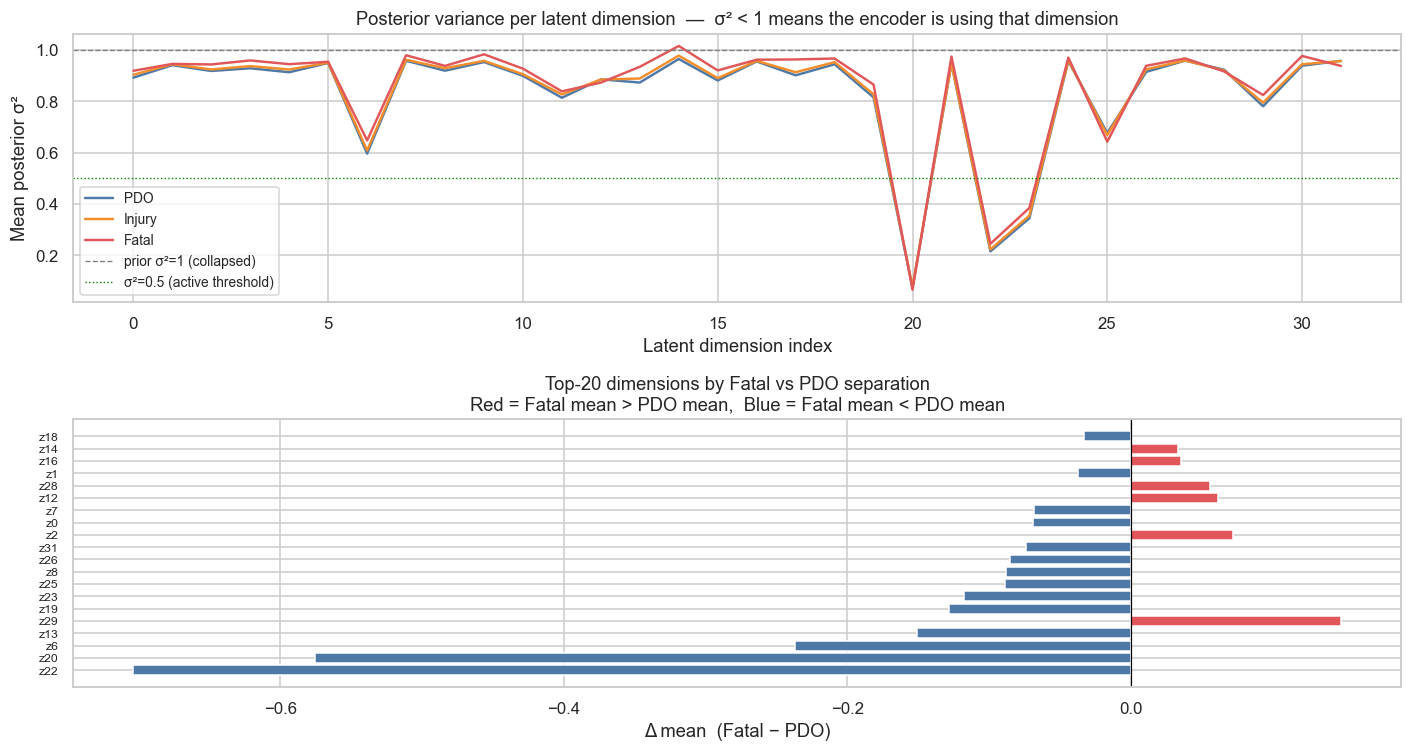

In [9]:
# Per-class mean posterior σ²
class_var   = np.stack([np.exp(lv[y_all == i]).mean(axis=0) for i in range(3)])
class_means = np.stack([Z[y_all == i].mean(axis=0) for i in range(3)])
fatal_vs_pdo = class_means[2] - class_means[0]

n_active   = int((class_var.mean(axis=0) < 0.5).sum())
n_collapsed= int((class_var.mean(axis=0) > 0.9).sum())
print(f'Active dimensions  (σ² < 0.5): {n_active} / {Z.shape[1]}')
print(f'Collapsed dimensions (σ² > 0.9): {n_collapsed} / {Z.shape[1]}')

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Posterior variance
for cls_id, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    axes[0].plot(class_var[cls_id], label=name, color=color, linewidth=1.6)
axes[0].axhline(1.0, color='grey', linestyle='--', linewidth=0.9, label='prior σ²=1 (collapsed)')
axes[0].axhline(0.5, color='green', linestyle=':', linewidth=0.9, label='σ²=0.5 (active threshold)')
axes[0].set_xlabel('Latent dimension index')
axes[0].set_ylabel('Mean posterior σ²')
axes[0].set_title('Posterior variance per latent dimension  —  σ² < 1 means the encoder is using that dimension')
axes[0].legend(fontsize=9)

# Fatal vs PDO separation
top_n      = min(20, Z.shape[1])
sorted_idx = np.argsort(np.abs(fatal_vs_pdo))[::-1][:top_n]
bar_colors = ['#e15759' if v > 0 else '#4e79a7' for v in fatal_vs_pdo[sorted_idx]]
axes[1].barh(range(top_n), fatal_vs_pdo[sorted_idx], color=bar_colors)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([f'z{d}' for d in sorted_idx], fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Δ mean  (Fatal − PDO)')
axes[1].set_title(
    f'Top-{top_n} dimensions by Fatal vs PDO separation\n'
    'Red = Fatal mean > PDO mean,  Blue = Fatal mean < PDO mean'
)

plt.tight_layout()
plt.show()

### How to interpret

| Observation | What it means |
|---|---|
| Some dims have σ² ≪ 1 | Those dimensions encode real signal — the encoder didn't ignore them |
| Dims where σ² ≈ 1 | The encoder found no useful structure there; safe to ignore in downstream models |
| Δ mean (Fatal − PDO) non-zero | Fatal samples occupy a different region of Z — LSA will sample from a meaningful centroid |
| All three classes share a similar σ² profile | The encoder learned a shared structure, not class-specific paths |

### KL Divergence

KL divergence measures how much each latent dimension's posterior `q(z|x)` deviates from the
prior `p(z) = N(0, I)`.  It is the second term of the ELBO loss the VAE was trained to minimise.

- **Per-dimension KL**: which dimensions carry information vs which collapsed to the prior
- **Per-sample KL**: which samples are hardest for the encoder to compress
- **Per-class KL**: whether fatal crashes require a more expressive posterior than PDO crashes

Formula: `KL = -0.5 × Σ_d (1 + log_var_d − μ_d² − exp(log_var_d))`

Total KL (mean per sample)     : 4.4770 nats
Dimensions with KL < 0.01      : 4 / 32  (effectively collapsed)
Dimension with highest KL      : z20  (1.6694 nats)


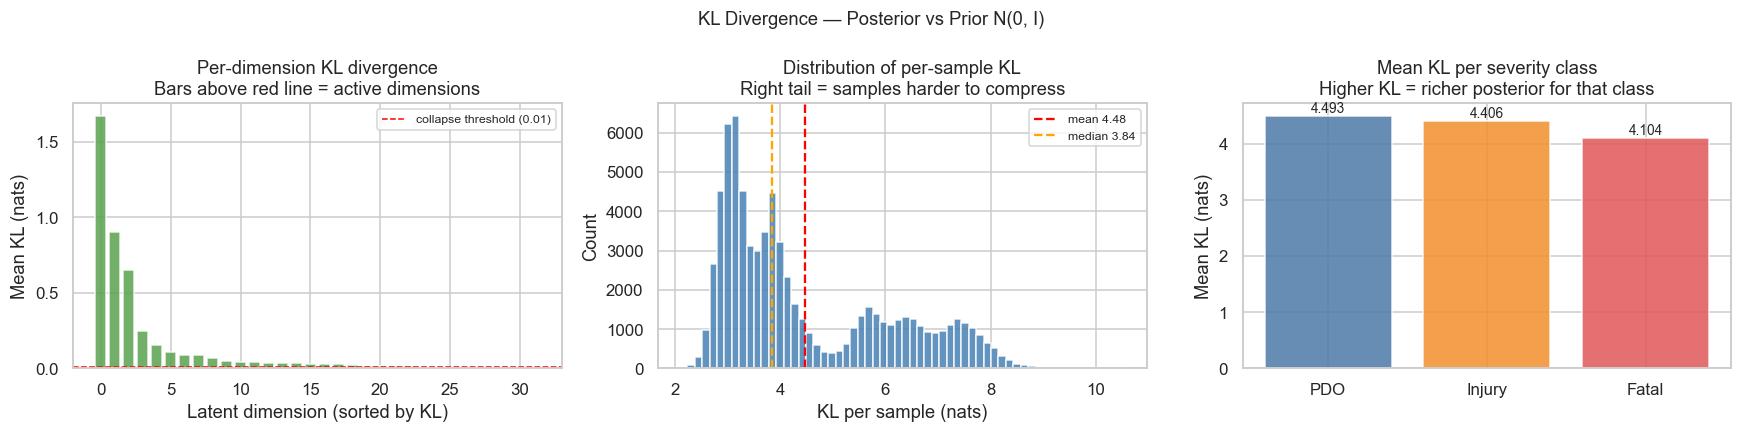

In [10]:
# KL per sample and per dimension  (closed-form for diagonal Gaussian posterior)
kl_per_dim    = -0.5 * (1 + lv - Z**2 - np.exp(lv))          # (N, latent_dim)
kl_per_sample = kl_per_dim.sum(axis=1)                        # (N,)
kl_per_dim_mean = kl_per_dim.mean(axis=0)                     # (latent_dim,)

n_collapsed_kl = int((kl_per_dim_mean < 0.01).sum())
print(f'Total KL (mean per sample)     : {kl_per_sample.mean():.4f} nats')
print(f'Dimensions with KL < 0.01      : {n_collapsed_kl} / {Z.shape[1]}  (effectively collapsed)')
print(f'Dimension with highest KL      : z{kl_per_dim_mean.argmax()}  ({kl_per_dim_mean.max():.4f} nats)')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Per-dimension KL
axes[0].bar(range(Z.shape[1]), np.sort(kl_per_dim_mean)[::-1], color='#59a14f', alpha=0.85)
axes[0].axhline(0.01, color='red', linestyle='--', linewidth=1.0, label='collapse threshold (0.01)')
axes[0].set_xlabel('Latent dimension (sorted by KL)')
axes[0].set_ylabel('Mean KL (nats)')
axes[0].set_title('Per-dimension KL divergence\nBars above red line = active dimensions')
axes[0].legend(fontsize=8)

# Per-sample KL distribution
axes[1].hist(kl_per_sample, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(kl_per_sample.mean(),   color='red',    linestyle='--', linewidth=1.5,
                label=f'mean {kl_per_sample.mean():.2f}')
axes[1].axvline(np.median(kl_per_sample), color='orange', linestyle='--', linewidth=1.5,
                label=f'median {np.median(kl_per_sample):.2f}')
axes[1].set_xlabel('KL per sample (nats)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of per-sample KL\nRight tail = samples harder to compress')
axes[1].legend(fontsize=8)

# Per-class mean KL
class_kl = [kl_per_sample[y_all == i].mean() for i in range(3)]
bars = axes[2].bar(CLASS_NAMES, class_kl, color=CLASS_COLORS, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, class_kl):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('Mean KL (nats)')
axes[2].set_title('Mean KL per severity class\nHigher KL = richer posterior for that class')

plt.suptitle('KL Divergence — Posterior vs Prior N(0, I)', fontsize=12)
plt.tight_layout()
plt.show()

### How to interpret

| Observation | What it means |
|---|---|
| Most dims have KL ≈ 0 | Posterior collapse — encoder only used a handful of dimensions; latent space is low-rank |
| One dim has very high KL | All information was funnelled into a single dimension (consistent with PC1 ≈ 100%) |
| Fatal class has higher KL than PDO | The encoder needed a richer posterior to represent fatal crashes — they are genuinely harder to compress |
| Long right tail in per-sample KL | A small subset of samples is encoded very differently from the prior — possible outliers or rare road configurations |

> **Action**: if most dims are collapsed, consider reducing `β` in `params.yaml` (weaker KL penalty)  
> or reducing `latent_dim`. A smaller but fully-active latent space is more useful than a large collapsed one.

---
## §3 — LSA readiness: is the fatal cluster usable?

LSA (Latent Space Augmentation) works by:
1. Finding all real fatal samples in `Z_train`
2. Computing their centroid (mean) and spread (std) per dimension
3. Sampling synthetic fatal vectors from `N(centroid, spread)`
4. Appending them to `Z_train` until the fatal fraction reaches the target ratio

For this to produce *useful* synthetics, the fatal cluster must:
- Be reasonably compact (low std → synthetics stay close to real fatals)
- Be distinct from the PDO centroid (non-zero separation → synthetics don't look like PDO)

A high std means the fatal class is spread widely in that dimension — synthetics will scatter broadly
and may overlap with PDO/Injury, which could degrade classifier performance.

Real fatal samples in Z_train : 63
Synthetic samples added       : 7794
Fatal fraction after LSA      : 15.00%  (target 5%)
Fatal cluster mean std        : 0.316
Avg normalised separation     : 0.200  (> 1 = distinct)


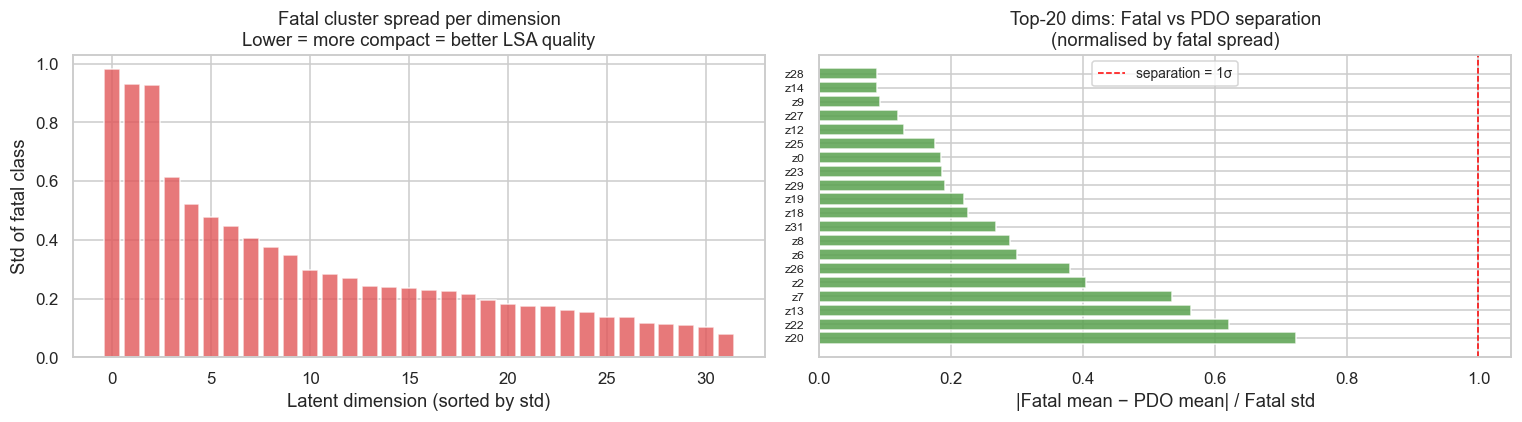

In [11]:
Z_train_real = Z[:len(X_train)]
y_train_real = y_all[:len(X_train)]

z_fatal = Z_train_real[y_train_real == 2]
z_pdo   = Z_train_real[y_train_real == 0]

fatal_mean = z_fatal.mean(axis=0)
fatal_std  = z_fatal.std(axis=0, ddof=1)
pdo_mean   = z_pdo.mean(axis=0)

# Mahalanobis-like: separation normalised by fatal spread
separation = np.abs(fatal_mean - pdo_mean) / np.maximum(fatal_std, 1e-6)

n_real_fatal = len(z_fatal)
Z_aug        = np.load(PROCESSED / 'Z_train_augmented.npy')
n_synthetic  = len(Z_aug) - len(Z_train_real)
fatal_frac   = (np.load(PROCESSED / 'y_train_augmented.npy') == 2).mean()

print(f'Real fatal samples in Z_train : {n_real_fatal}')
print(f'Synthetic samples added       : {n_synthetic}')
print(f'Fatal fraction after LSA      : {fatal_frac:.2%}  (target 5%)')
print(f'Fatal cluster mean std        : {fatal_std.mean():.3f}')
print(f'Avg normalised separation     : {separation.mean():.3f}  (> 1 = distinct)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fatal std per dim
axes[0].bar(range(len(fatal_std)), np.sort(fatal_std)[::-1], color='#e15759', alpha=0.8)
axes[0].set_xlabel('Latent dimension (sorted by std)')
axes[0].set_ylabel('Std of fatal class')
axes[0].set_title('Fatal cluster spread per dimension\nLower = more compact = better LSA quality')

# Normalised separation per dim (top 20 or all dims if < 20)
n_top = min(20, len(separation))
top_sep_idx = np.argsort(separation)[::-1][:n_top]
axes[1].barh(range(n_top), separation[top_sep_idx], color='#59a14f', alpha=0.85)
axes[1].set_yticks(range(n_top))
axes[1].set_yticklabels([f'z{d}' for d in top_sep_idx], fontsize=8)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.0, label='separation = 1σ')
axes[1].set_xlabel('|Fatal mean − PDO mean| / Fatal std')
axes[1].set_title(f'Top-{n_top} dims: Fatal vs PDO separation\n(normalised by fatal spread)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### How to interpret

| Observation | What it means |
|---|---|
| Low fatal std across dims | Cluster is compact; synthetics will closely resemble real fatals — good |
| High fatal std in a dim | Encoder places fatals loosely in that direction; synthetics may look like PDO |
| Normalised separation > 1 in several dims | Fatal and PDO occupy clearly different regions — synthetics won't pollute the PDO neighbourhood |
| n_synthetic ≫ n_real_fatal | LSA is doing heavy augmentation; classifier will train mostly on synthetic fatals — monitor for overfit |

---
## §4 — Reconstruction sanity check *(secondary)*

The decoder is never called at inference time. We use it here as a **proxy for encoder quality**:
if the encoder completely ignored a feature, the decoder cannot reconstruct it and the MSE for
that feature will be high.

> **Important**: high per-feature MSE does **not** mean the pipeline is broken.  
> It means the encoder did not find that feature useful for building a compact latent code.
> The encoder may still produce a `Z` that the classifier can use — what matters is §1 (class separation).

Features with high MSE are candidates to investigate further (e.g. MONTH suffers from ordinal
encoding of a circular variable; fixing the encoding may improve both reconstruction and classification).

Overall RMSE (scaled space): 0.9894
Worst feature              : CRASHTYPE  (MSE=3.51)
Best feature               : NONTRAFFIC  (MSE=0.0009)


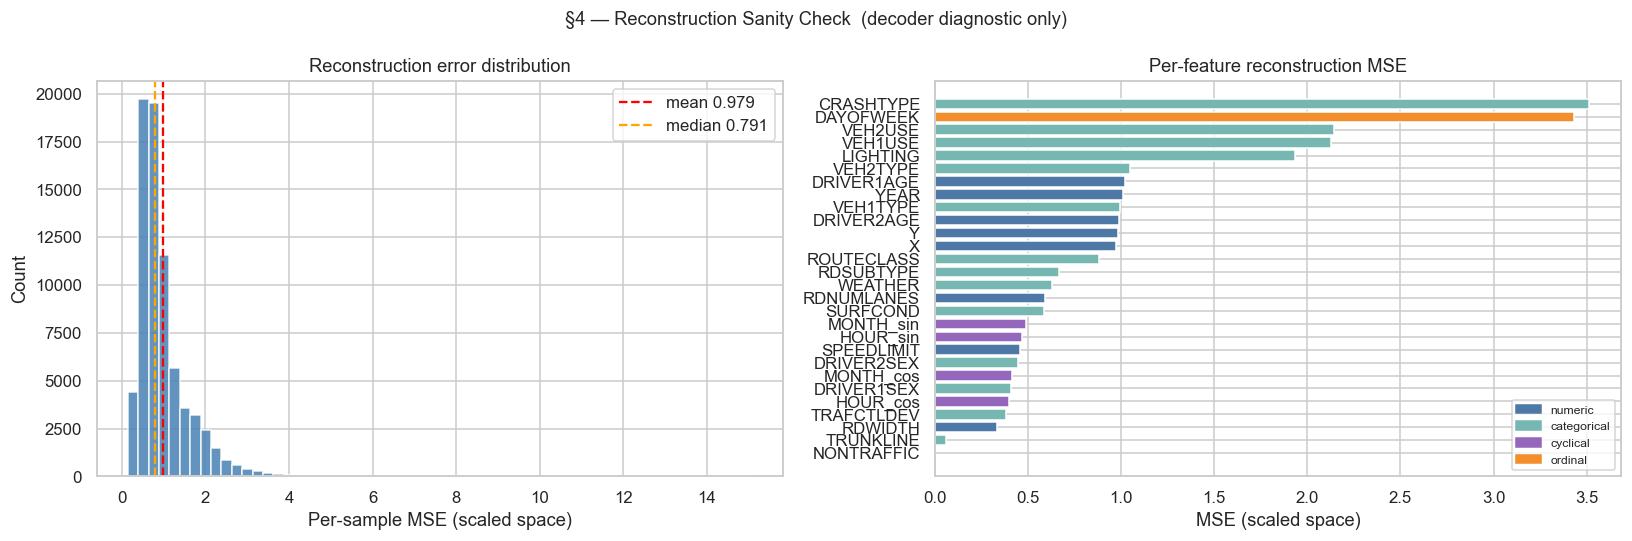

In [12]:
mse_per_sample = np.mean((X_all - X_r) ** 2, axis=1)
feat_mse       = np.mean((X_all - X_r) ** 2, axis=0)
overall_rmse   = float(np.sqrt(mse_per_sample.mean()))

print(f'Overall RMSE (scaled space): {overall_rmse:.4f}')
print(f'Worst feature              : {feature_names[feat_mse.argmax()]}  (MSE={feat_mse.max():.2f})')
print(f'Best feature               : {feature_names[feat_mse.argmin()]}  (MSE={feat_mse.min():.4f})')

TYPE_COLOR = {
    'numeric': '#4e79a7', 
    'categorical': '#76b7b2', 
    'cyclical': '#9467bd',
    'ordinal': '#f28e2b'
}
mse_df = (
    pd.DataFrame({'feature': feature_names, 'type': feature_type, 'mse': feat_mse})
    .sort_values('mse', ascending=True)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Per-sample MSE distribution
axes[0].hist(mse_per_sample, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(mse_per_sample.mean(),   color='red',    linestyle='--', linewidth=1.5,
                label=f'mean {mse_per_sample.mean():.3f}')
axes[0].axvline(np.median(mse_per_sample), color='orange', linestyle='--', linewidth=1.5,
                label=f'median {np.median(mse_per_sample):.3f}')
axes[0].set_xlabel('Per-sample MSE (scaled space)')
axes[0].set_ylabel('Count')
axes[0].set_title('Reconstruction error distribution')
axes[0].legend()

# Per-feature MSE
colors = list(mse_df['type'].map(TYPE_COLOR))
axes[1].barh(mse_df['feature'], mse_df['mse'], color=colors, edgecolor='white')
axes[1].set_xlabel('MSE (scaled space)')
axes[1].set_title('Per-feature reconstruction MSE')
handles = [mpatches.Patch(color=v, label=k) for k, v in TYPE_COLOR.items()]
axes[1].legend(handles=handles, loc='lower right', fontsize=8)

plt.suptitle('§4 — Reconstruction Sanity Check  (decoder diagnostic only)', fontsize=12)
plt.tight_layout()
plt.show()

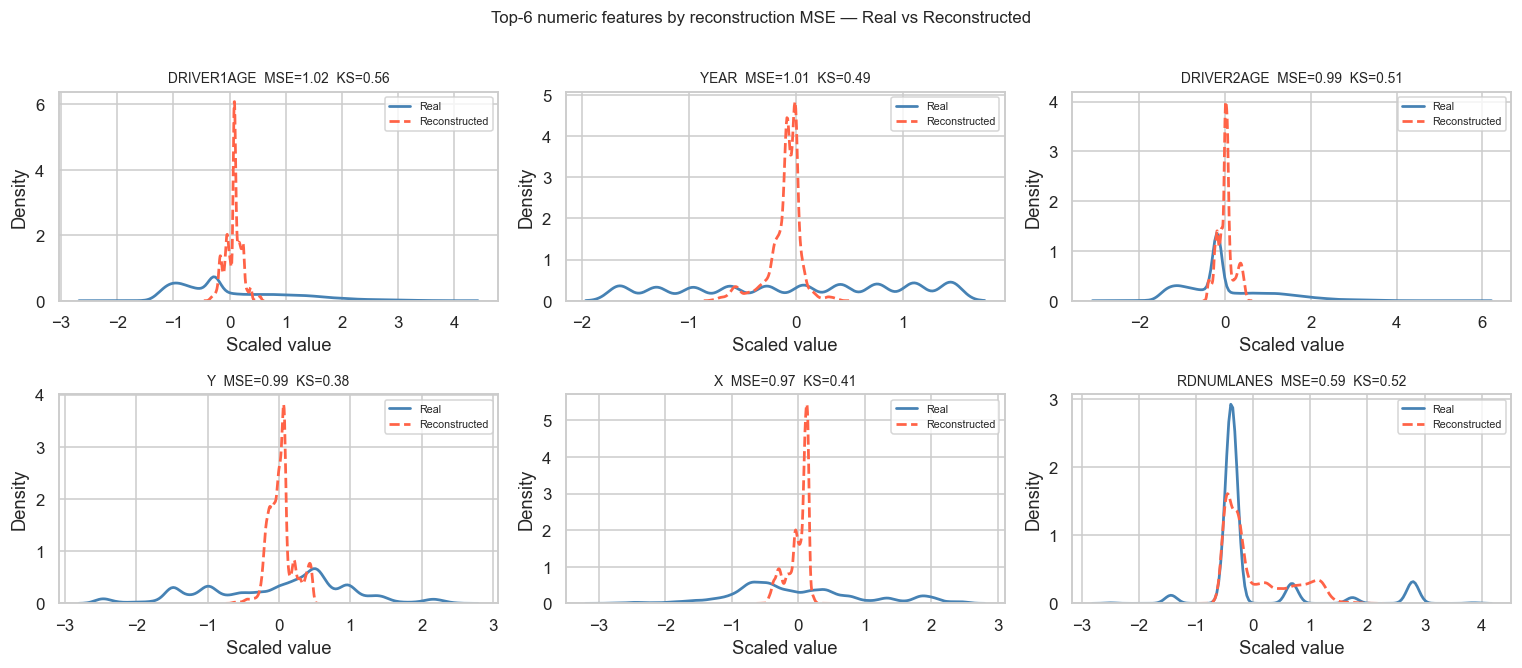

In [13]:
# KDE: real vs reconstructed for the 6 numeric features with highest MSE
num_idx = [i for i, t in enumerate(feature_type) if t == 'numeric']
num_by_mse = sorted(num_idx, key=lambda i: feat_mse[i], reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, feat_i in zip(axes.flatten(), num_by_mse):
    sns.kdeplot(X_all[:, feat_i], ax=ax, color='steelblue', linewidth=1.8, label='Real')
    sns.kdeplot(X_r[:, feat_i],   ax=ax, color='tomato',    linewidth=1.8, linestyle='--', label='Reconstructed')
    ks = stats.ks_2samp(X_all[:, feat_i], X_r[:, feat_i]).statistic
    ax.set_title(f'{feature_names[feat_i]}  MSE={feat_mse[feat_i]:.2f}  KS={ks:.2f}', fontsize=9)
    ax.set_xlabel('Scaled value'); ax.legend(fontsize=7)

fig.suptitle('Top-6 numeric features by reconstruction MSE — Real vs Reconstructed',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## Summary of findings

In [14]:
pca_full = PCA(random_state=42).fit(Z)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_90     = int(np.searchsorted(cum_var, 90)) + 1

avg_sep  = float(separation.mean())

findings = pd.DataFrame([
    ('§1 — Class separation',   'PC1+PC2 variance',       f'{var_exp[0]+var_exp[1]:.1f}%'),
    ('§1 — Class separation',   'PCA dims for 90% var',   f'{n_90} / {Z.shape[1]}'),
    ('§2 — Encoder quality',    'Active dims (σ² < 0.5)', f'{n_active} / {Z.shape[1]}'),
    ('§2 — Encoder quality',    'Collapsed dims (σ² > 0.9)', f'{n_collapsed} / {Z.shape[1]}'),
    ('§3 — LSA readiness',      'Real fatal samples',      str(n_real_fatal)),
    ('§3 — LSA readiness',      'Synthetic samples added', f'{n_synthetic:,}'),
    ('§3 — LSA readiness',      'Fatal fraction after LSA', f'{fatal_frac:.1%}'),
    ('§3 — LSA readiness',      'Avg normalised separation', f'{avg_sep:.3f}'),
    ('§4 — Reconstruction',     'Overall RMSE',            f'{overall_rmse:.4f}'),
    ('§4 — Reconstruction',     'Worst feature (MSE)',      f'{feature_names[feat_mse.argmax()]} ({feat_mse.max():.2f})'),
], columns=['Section', 'Metric', 'Value'])

display(
    findings.style
    .set_caption('VAE Phase 3E — Summary of findings')
    .hide(axis='index')
)

Section,Metric,Value
§1 — Class separation,PC1+PC2 variance,56.9%
§1 — Class separation,PCA dims for 90% var,5 / 32
§2 — Encoder quality,Active dims (σ² < 0.5),3 / 32
§2 — Encoder quality,Collapsed dims (σ² > 0.9),21 / 32
§3 — LSA readiness,Real fatal samples,63
§3 — LSA readiness,Synthetic samples added,"7,794"
§3 — LSA readiness,Fatal fraction after LSA,15.0%
§3 — LSA readiness,Avg normalised separation,0.200
§4 — Reconstruction,Overall RMSE,0.9894
§4 — Reconstruction,Worst feature (MSE),CRASHTYPE (3.51)
